In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Problem 1 — Constructing a Grouped Frequency Distribution
Question:

The following are the marks (out of 50) obtained by 20 students in a test:

12, 25, 34, 45, 22, 17, 30, 48, 29, 41,

33, 26, 19, 28, 39, 44, 31, 24, 15, 37

Construct a grouped frequency distribution table using class intervals of width 10, starting from 10–20.

In [2]:
# Create a pandas dataframe
data = { "marks" : [12, 25, 34, 45, 22, 17, 30, 48, 29, 41, 33, 26, 19, 28, 39, 44, 31, 24, 15, 37]}
df = pd.DataFrame(data)

# Define bins and labels
bins = [10, 20, 30, 40, 50]
labels = ['10–20', '20–30', '30–40', '40–50']

# Create grouped frequency table
df['Interval'] = pd.cut(df['marks'], bins=bins, labels=labels)
freq_table = df['Interval'].value_counts().sort_index()

freq_table

,count
Interval,
10–20,4
20–30,7
30–40,5
40–50,4


### Problem 2 — Relative Frequency Distribution
Question:

Using the above frequency table, calculate the relative frequency for each class.

In [3]:
# Calculate relative frequency
relative_freq = freq_table / freq_table.sum()
relative_freq

,count
Interval,
10–20,0.20
20–30,0.35
30–40,0.25
40–50,0.20


### Problem 3 — Cumulative Frequency Distribution (Less-Than Type)
Question:

Construct the less-than cumulative frequency for the dataset in Problem 1.

In [4]:
cum_freq = freq_table.cumsum()
cum_freq

,count
Interval,
10–20,4
20–30,11
30–40,16
40–50,20


### Problem 4 — Coefficient of Variation
Question:

A dataset has a mean (X̄) = 40 and a standard deviation (σ) = 8. Find the Coefficient of Variation (CoV) and interpret the result.

In [5]:
std_dev = 8
mean = 40


coefficient_of_variation = (std_dev / mean) * 100
coefficient_of_variation

# The data shows moderate variability, meaning the observations are fairly consistent around the mean value of 40.

20.0

### Problem 5 — Correlation Coefficient
Question:

The following table shows the marks obtained by 5 students in Mathematics and Physics:

|Student|Math (X)|Physics (Y)|
|---|---|---|
|A|3|30|
|B|4|40|
|C|4|50|
|D|5|45|
|E|5|60|

Calculate the Karl Pearson’s correlation coefficient (r) between marks in Mathematics and Physics

In [6]:
data = {
    'Student' : ['A', 'B', 'C', 'D', 'E'],
    'Maths': [35, 40, 45, 50, 55],
    'Physics': [30, 40, 50, 45, 60]
}

df = pd.DataFrame(data)
df = df.set_index('Student')

correlation = df['Maths'].corr(df['Physics'])
print(f"Pearson correlation between Maths and Physics: {correlation}")

Pearson correlation between Maths and Physics: 0.9192388155425117


### Problem 6 — Histogram Construction
Question:

The table below shows the number of students who scored marks (out of 100) in a DataScience exam.

|Marks Range|Frequency|
|---|---|
|0–20|4|
|20–40|6|
|40–60|10|
|60–80|8|
|80–100|2|

- Construct a Histogram representing the frequency distribution.
- Identify the class interval with the highest frequency (the mode class).

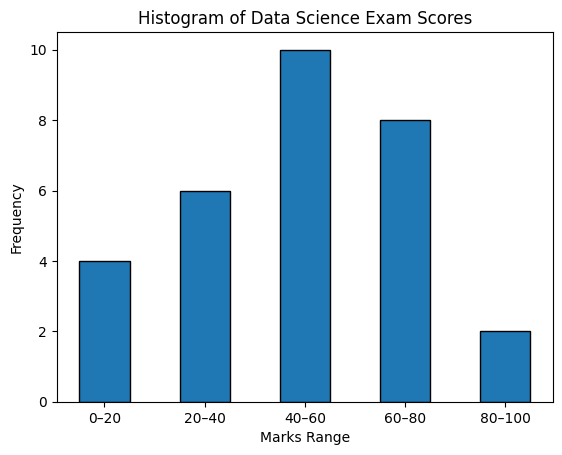

The mode class is: 40–60


In [7]:
marks_range = ['0–20', '20–40', '40–60', '60–80', '80–100']
frequencies = [4, 6, 10, 8, 2]

plt.bar(marks_range, frequencies, width=0.5, edgecolor='black')
plt.xlabel('Marks Range')
plt.ylabel('Frequency')
plt.title('Histogram of Data Science Exam Scores')
plt.show()

max_freq = max(frequencies)
mode_class = marks_range[frequencies.index(max_freq)]
print(f"The mode class is: {mode_class}")

### Problem 7 — Bar Plot Comparison
Question:

The table below shows the number of publications made by three departments over four years.

|Year|CS Dept|ECE Dept|Mech Dept|
|---|---|---|---|
|2022|25|20|15|
|2023|30|25|20|
|2024|35|30|25|
|2025|40|28|30|

- Plot a grouped bar chart comparing the departments over the years.
- Which department shows the highest overall growth?

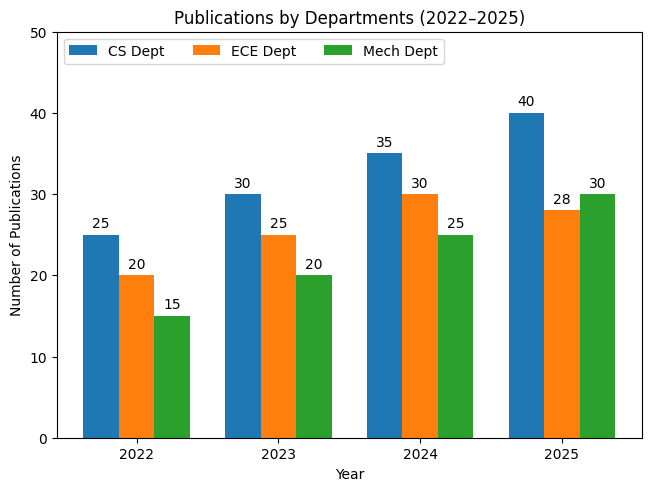

Department(s) with the highest overall growth: CS Dept, Mech Dept


In [8]:
years = (2022, 2023, 2024, 2025)

departments = {
'CS Dept' : (25, 30, 35, 40),
'ECE Dept' : (20, 25, 30, 28),
'Mech Dept' : (15, 20, 25, 30)
}

x = np.arange(len(years))
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in departments.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

ax.set_xlabel('Year')
ax.set_ylabel('Number of Publications')
ax.set_title('Publications by Departments (2022–2025)')
ax.set_xticks(x + width, years)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 50)
plt.show()


growth = {dept: values[-1] - values[0] for dept, values in departments.items()}
max_growth = max(growth.values())
highest_growth = [dept for dept, g in growth.items() if g == max_growth]

print("Department(s) with the highest overall growth:", ', '.join(highest_growth))
